# Workshop: Bildklassifikation mit neuronalen Netzen

## Müllklassifikation mit drei verschiedenen Netzarchitekturen

In diesem Workshop lernen Sie Schritt für Schritt verschiedene Arten von neuronalen Netzen
kennen und vergleichen deren Leistung bei der Bildklassifikation.

Wir trainieren drei Modelle:

1. **Einfaches Feed-Forward-Netz (MLP)** – unser Basismodell, das Bilder nicht wirklich „versteht“
2. **Eigenes CNN** – speziell für Bilder gebaut, erkennt Muster und Kanten
3. **Vortrainiertes EfficientNetB0** – modernes Transfer-Learning-Modell

---

## Lernziele

Nach diesem Workshop können Sie:
- verstehen, wie neuronale Netze Schritt für Schritt lernen
- den Unterschied zwischen MLPs und CNNs erklären
- Transfer Learning verstehen und einsetzen
- Trainingsverläufe grafisch lesen und interpretieren
- Modelle mit einer Confusion Matrix detailliert auswerten
- Einzelvorhersagen visualisieren und bewerten

---

## Warum genau diese drei Modelle?

| Modell | Neue Lektion |
|---|---|
| MLP | Warum einfache Netze für Bilder nicht gut funktionieren |
| Eigenes CNN | Warum räumliches Verständnis entscheidend ist |
| EfficientNetB0 | Wie Transfer Learning mit wenig Training sehr gute Ergebnisse liefert |


---

## Erwartete Ordnerstruktur

```text
data/garbage_classification_enhanced_500/
├── train/
│   ├── battery/
│   ├── cardboard/
│   ├── plastic/
│   └── ...
└── test/
    ├── battery/
    ├── cardboard/
    └── ...
```

Jeder Unterordner entspricht einer Klasse.
Der Name des Ordners wird automatisch als Klassenname verwendet.

---

## Schritt 1 – Pfade festlegen

Bevor wir irgendetwas trainieren, teilen wir Python mit, **wo unsere Bilder liegen**.

Wir speichern die Pfade in Variablen, damit wir sie später nicht an vielen
verschiedenen Stellen einzeln ändern müssen – nur hier an einer einzigen Stelle.

> **Hinweis:** Wenn Ihr Datensatz an einem anderen Ort gespeichert ist,
> ändern Sie nur die Variable `DATA_DIR` in der nächsten Zelle.

In [1]:
from pathlib import Path

DATA_DIR  = Path("./data/garbage_classification_enhanced_500")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR  = DATA_DIR / "test"

print("Pfade festgelegt:")
print(f"  Trainingsdaten : {TRAIN_DIR}")
print(f"  Testdaten      : {TEST_DIR}")

Pfade festgelegt:
  Trainingsdaten : data\garbage_classification_enhanced_500\train
  Testdaten      : data\garbage_classification_enhanced_500\test


---

## Schritt 2 – Bibliotheken laden

Python kann nicht alles von Haus aus. Wir laden deshalb zusätzliche
**Bibliotheken** – das sind fertige Werkzeugsammlungen anderer Entwickler:

| Bibliothek | Wofür? |
|---|---|
| `numpy` | Rechnen mit großen Zahlenlisten |
| `matplotlib` | Grafiken und Diagramme zeichnen |
| `tensorflow` | Das eigentliche KI-Framework |
| `sklearn` | Auswertungswerkzeuge wie die Confusion Matrix |
| `json` | Konfigurationsdateien speichern und laden |

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("TensorFlow-Version:", tf.__version__)
print("Keras-Version     :", tf.keras.__version__)
print("Alle Bibliotheken erfolgreich geladen.")

TensorFlow-Version: 2.21.0
Keras-Version     : 3.15.0
Alle Bibliotheken erfolgreich geladen.


---

## Schritt 3 – Trainingseinstellungen festlegen

Bevor das Training startet, legen wir grundlegende Einstellungen fest.
Diese werden **Hyperparameter** genannt.

### Was bedeuten diese Einstellungen?

**Bildgröße für klassische Modelle (`IMG_SIZE_SMALL`)**
MLP und CNN bekommen kleinere Bilder mit 128×128 Pixeln.

**Bildgröße für Transfer Learning (`IMG_SIZE_TRANSFER`)**
EfficientNetB0 wurde ursprünglich auf **224×224 Pixeln** trainiert.
Das ist die offizielle Standardgröße dieses Modells.
Wir verwenden diese Größe, damit das vortrainierte Wissen optimal genutzt wird.

**Batchgröße (`BATCH_SIZE`)**
Das Netz verarbeitet nicht alle Bilder auf einmal, sondern immer eine kleine Gruppe.
32 Bilder pro Batch ist ein bewährter Standardwert.

**Seed (`SEED`)**
Viele Vorgänge im Training sind zufällig. Ein fester Seed sorgt für reproduzierbare Ergebnisse.

**Epochen**
Eine Epoche bedeutet: Das Netz hat einmal alle Trainingsbilder gesehen.
Das Transfer-Learning-Modell braucht deutlich weniger Epochen,
weil es bereits Vorwissen mitbringt.

In [3]:
IMG_SIZE_SMALL    = (128, 128)
IMG_SIZE_TRANSFER = (224, 224)  # Standardgröße für EfficientNetB0

BATCH_SIZE = 32
SEED       = 42

MLP_EPOCHS = 30
CNN_EPOCHS = 30
TL_EPOCHS  = 20

print("Einstellungen festgelegt:")
print(f"  Bildgröße MLP/CNN        : {IMG_SIZE_SMALL}")
print(f"  Bildgröße Transfer-Learn : {IMG_SIZE_TRANSFER}  (Standard EfficientNetB0)")
print(f"  Batchgröße               : {BATCH_SIZE}")
print(f"  MLP Epochen              : {MLP_EPOCHS}")
print(f"  CNN Epochen              : {CNN_EPOCHS}")
print(f"  Transfer Learning Epochen: {TL_EPOCHS}")

Einstellungen festgelegt:
  Bildgröße MLP/CNN        : (128, 128)
  Bildgröße Transfer-Learn : (224, 224)  (Standard EfficientNetB0)
  Batchgröße               : 32
  MLP Epochen              : 30
  CNN Epochen              : 30
  Transfer Learning Epochen: 20


---

## Schritt 4 – Datensatz prüfen

Bevor wir mit dem Training beginnen, überprüfen wir:
- Ist der Datensatz-Ordner vorhanden?
- Welche Klassen gibt es?
- Wie viele Bilder hat jede Klasse?

In [4]:
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Datensatz-Ordner nicht gefunden: {DATA_DIR}\n"
        "Bitte DATA_DIR in Schritt 1 anpassen."
    )

train_classes = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
test_classes  = sorted([p.name for p in TEST_DIR.iterdir()  if p.is_dir()])

print(f"Klassen im Trainings-Ordner ({len(train_classes)}):")
for name in train_classes:
    n = len(list((TRAIN_DIR / name).glob("*.*")))
    print(f"  {name:20s}: {n} Bilder")

print(f"\nKlassen im Test-Ordner ({len(test_classes)}):")
for name in test_classes:
    n = len(list((TEST_DIR / name).glob("*.*")))
    print(f"  {name:20s}: {n} Bilder")

if train_classes != test_classes:
    raise ValueError("ACHTUNG: Klassen in train/ und test/ stimmen nicht überein!")
else:
    print("\nOK: Klassen in train/ und test/ stimmen überein.")

Klassen im Trainings-Ordner (12):
  battery             : 500 Bilder
  biological          : 500 Bilder
  brown-glass         : 500 Bilder
  cardboard           : 500 Bilder
  clothes             : 500 Bilder
  green-glass         : 500 Bilder
  metal               : 500 Bilder
  paper               : 500 Bilder
  plastic             : 500 Bilder
  shoes               : 500 Bilder
  trash               : 500 Bilder
  white-glass         : 500 Bilder

Klassen im Test-Ordner (12):
  battery             : 100 Bilder
  biological          : 100 Bilder
  brown-glass         : 100 Bilder
  cardboard           : 100 Bilder
  clothes             : 100 Bilder
  green-glass         : 100 Bilder
  metal               : 100 Bilder
  paper               : 100 Bilder
  plastic             : 100 Bilder
  shoes               : 100 Bilder
  trash               : 100 Bilder
  white-glass         : 100 Bilder

OK: Klassen in train/ und test/ stimmen überein.


---

## Schritt 5 – Bilder laden

Jetzt laden wir die Bilder aus den Ordnern in Python.

Die Funktion `image_dataset_from_directory` erledigt automatisch:
- das Einlesen der Bilder
- das Verkleinern auf eine feste Größe
- das Vergeben numerischer Labels

**Warum `shuffle=True` beim Training, aber `shuffle=False` beim Test?**

Beim Training mischen wir die Bilder, damit das Modell nicht einfach die Reihenfolge lernt.
Beim Testen bleibt die Reihenfolge fest, damit Vorhersagen und echte Labels sauber zusammenpassen.

**Was ist `prefetch`?**

Während das Netz einen Batch verarbeitet, lädt `prefetch` im Hintergrund schon den nächsten.
Das macht das Training schneller.

**Warum zwei Datensätze?**

- `train_ds` / `val_ds` in 128×128 für MLP und CNN
- `train_ds_transfer` / `val_ds_transfer` in 224×224 für EfficientNetB0

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

# --- Datensatz 128×128 (für MLP und CNN) ---
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE_SMALL,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE_SMALL,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)
train_ds = train_ds_raw.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds_raw.prefetch(buffer_size=AUTOTUNE)

# --- Datensatz 224×224 (für EfficientNetB0) ---
train_ds_transfer_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE_TRANSFER,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)
val_ds_transfer_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE_TRANSFER,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)
train_ds_transfer = train_ds_transfer_raw.prefetch(buffer_size=AUTOTUNE)
val_ds_transfer   = val_ds_transfer_raw.prefetch(buffer_size=AUTOTUNE)

class_names = train_ds_raw.class_names
num_classes = len(class_names)

print(f"Anzahl Klassen : {num_classes}")
print(f"Klassennamen   : {class_names}")
print("\nAlle Datensätze geladen und bereit.")

Found 6000 files belonging to 12 classes.
Found 1200 files belonging to 12 classes.
Found 6000 files belonging to 12 classes.
Found 1200 files belonging to 12 classes.
Anzahl Klassen : 12
Klassennamen   : ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']

Alle Datensätze geladen und bereit.


### Klassenverteilung prüfen

Ein **ausgeglichener Datensatz** hat ungefähr gleich viele Bilder pro Klasse.
Falls manche Klassen viel häufiger vorkommen als andere,
lernt das Modell diese bevorzugt.

Darum schauen wir uns die Verteilung früh an.

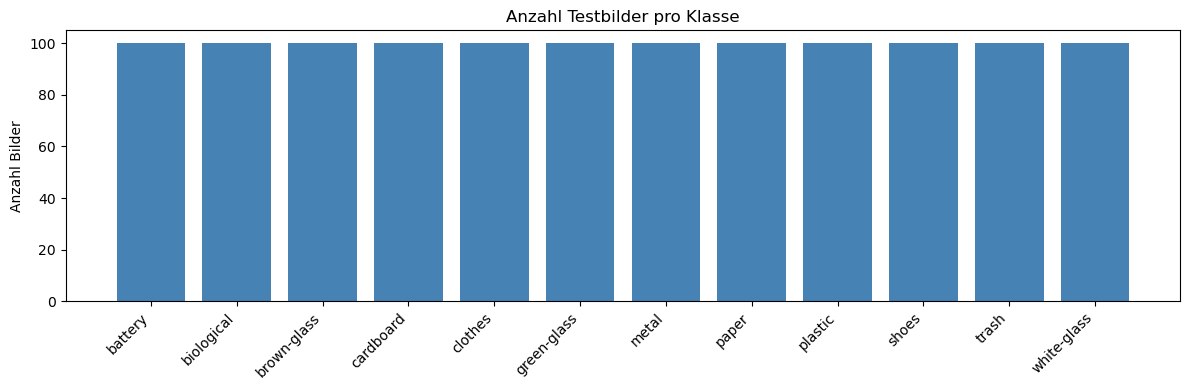

Gesamt: 1200 Testbilder


In [6]:
label_counts = np.zeros(num_classes, dtype=int)
for _, labels in val_ds_raw:
    for lbl in labels.numpy():
        label_counts[lbl] += 1

plt.figure(figsize=(12, 4))
plt.bar(class_names, label_counts, color="steelblue")
plt.title("Anzahl Testbilder pro Klasse")
plt.ylabel("Anzahl Bilder")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"Gesamt: {label_counts.sum()} Testbilder")

---

## Schritt 6 – Datenaugmentation

Unser Datensatz ist endlich – es gibt nur eine begrenzte Anzahl Bilder.
Mit **Datenaugmentation** erzeugen wir beim Training künstlich neue Varianten:

- gespiegelt
- leicht gedreht
- leicht gezoomt
- Kontrast leicht verändert

Dadurch wird das Modell robuster.

**Wichtig:** Die Augmentation ist nur beim Training aktiv.
Beim Testen bekommt das Modell die Originalbilder.

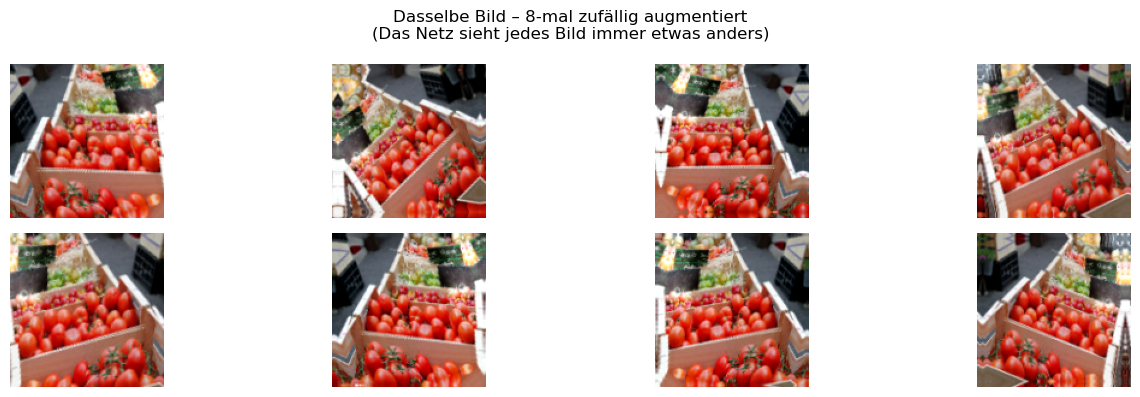

In [7]:
data_augmentation_small = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="augmentation_small")

data_augmentation_transfer = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="augmentation_transfer")

for images, _ in train_ds_raw.take(1):
    sample_image = images[0]

plt.figure(figsize=(14, 4))
plt.suptitle(
    "Dasselbe Bild – 8-mal zufällig augmentiert\n"
    "(Das Netz sieht jedes Bild immer etwas anders)",
    fontsize=12
)
for i in range(8):
    aug = data_augmentation_small(tf.expand_dims(sample_image, 0), training=True)
    plt.subplot(2, 4, i + 1)
    plt.imshow(aug[0].numpy().astype("uint8"))
    plt.axis("off")
plt.tight_layout()
plt.show()

---

## Schritt 7 – Modell-Builder definieren

Hier beschreiben wir jede Modell-Architektur als Python-Funktion.

Das hat große Vorteile:
- Das Training bleibt übersichtlich
- Die Architektur ist sauber dokumentiert
- Das Demo-Notebook kann dieselbe Architektur später wieder aufbauen

In [24]:
def build_mlp(num_classes, img_size):
    return Sequential([
        layers.Input(shape=(*img_size, 3)),
        data_augmentation_small,
        layers.Rescaling(1. / 255),
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ], name="mlp_model")


def build_cnn(num_classes, img_size):
    return Sequential([
        layers.Input(shape=(*img_size, 3)),
        data_augmentation_small,
        layers.Rescaling(1.0 / 255),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ], name="cnn_from_scratch")


def build_efficientnet_b0(num_classes, img_size, augmentation, weights="imagenet"):
    # EfficientNetB0 Standardbildgröße: 224×224
    # Das Modell normalisiert Pixelwerte intern – kein Rescaling nötig
    base = tf.keras.applications.EfficientNetB0(
        input_shape=(*img_size, 3),
        include_top=False,
        weights=weights
    )
    base.trainable = False
    return Sequential([
        layers.Input(shape=(*img_size, 3)),
        augmentation,
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax")
    ], name="efficientnetb0_model")


print("Alle Modell-Builder definiert.")

Alle Modell-Builder definiert.


---

## Schritt 8 – Trainingsverlauf verstehen und plotten

Nach jedem Training schauen wir uns zwei Kurven an:

**Accuracy**
Wie viel Prozent der Bilder wurden richtig klassifiziert?

**Loss**
Wie groß ist der Fehler des Modells im Durchschnitt?

Beide Kurven gibt es für Training und Validierung.

### Typische Interpretationen

| Situation | Bedeutung |
|---|---|
| Beide Kurven verbessern sich | Gut |
| Training viel besser als Validierung | Overfitting |
| Beide verbessern sich kaum | Underfitting |

In [9]:
def plot_history(history, title="Trainingsverlauf"):
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochen  = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14)

    ax1.plot(epochen, acc,     label="Training",    color="royalblue")
    ax1.plot(epochen, val_acc, label="Validierung", color="tomato", linestyle="--")
    ax1.set_title("Genauigkeit (Accuracy) – höher ist besser")
    ax1.set_xlabel("Epoche")
    ax1.set_ylabel("Accuracy")
    ax1.set_ylim(0, 1)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochen, loss,     label="Training",    color="royalblue")
    ax2.plot(epochen, val_loss, label="Validierung", color="tomato", linestyle="--")
    ax2.set_title("Verlust (Loss) – niedriger ist besser")
    ax2.set_xlabel("Epoche")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Hilfsfunktion 'plot_history' definiert.")

Hilfsfunktion 'plot_history' definiert.


---

# Teil 1: Einfaches Feed-Forward-Netz (MLP)

Ein **MLP** ist die einfachste Form eines neuronalen Netzes.
Es ist gut als Ausgangspunkt – aber für Bilder nicht optimal, weil das Bild mit `Flatten()` zu einer langen Zahlenliste wird.
Dabei geht die räumliche Struktur verloren.

Das MLP zeigt uns also, wie weit man **ohne echtes Bildverständnis** kommt.

### Die wichtigsten Schichten

| Schicht | Was sie tut |
|---|---|
| `Rescaling(1/255)` | Pixelwerte von 0–255 auf 0.0–1.0 skalieren |
| `Flatten()` | Bild in eine lange Zahlenreihe umwandeln |
| `Dense(512)` | 512 Neuronen, vollständig verbunden |
| `Dropout(0.3)` | 30 % der Neuronen zufällig abschalten – verhindert Auswendiglernen |
| `Dense(num_classes, softmax)` | Ausgabe als Wahrscheinlichkeit pro Klasse |

In [10]:
mlp_model = build_mlp(num_classes, IMG_SIZE_SMALL)
mlp_model.summary()

Model: "mlp_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ augmentation_small (Sequential)      │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 49152)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      25,166,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 12)                  │           3,084 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,300,748 (96.51 MB)

 Trainable params: 25,300,748 (96.51 MB)

 Non-trainable params: 0 (0.00 B)

### Modell kompilieren

Bevor das Training startet, müssen wir dem Modell sagen:
- wie es lernen soll – **Optimizer `Adam`**
- wie Fehler gemessen werden – **Loss**
- was wir beobachten möchten – **Accuracy**

In [11]:
mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"Starte MLP-Training ({MLP_EPOCHS} Epochen) ...")
history_mlp = mlp_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MLP_EPOCHS
)

Starte MLP-Training (30 Epochen) ...
Epoch 1/30


C:\Users\mathi\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


188/188 ━━━━━━━━━━━━━━━━━━━━ 39s 189ms/step - accuracy: 0.1190 - loss: 2.7173 - val_accuracy: 0.1233 - val_loss: 2.4107
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 36s 191ms/step - accuracy: 0.1520 - loss: 2.3772 - val_accuracy: 0.2100 - val_loss: 2.2572
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 36s 189ms/step - accuracy: 0.1952 - loss: 2.2756 - val_accuracy: 0.2942 - val_loss: 2.1062
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 35s 188ms/step - accuracy: 0.2135 - loss: 2.1940 - val_accuracy: 0.2817 - val_loss: 2.0257
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 35s 187ms/step - accuracy: 0.2178 - loss: 2.1477 - val_accuracy: 0.3033 - val_loss: 2.0407
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 36s 189ms/step - accuracy: 0.2398 - loss: 2.1175 - val_accuracy: 0.3350 - val_loss: 1.9483
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 35s 188ms/step - accuracy: 0.2410 - loss: 2.0975 - val_accuracy: 0.3175 - val_loss: 1.9302
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 35s 187ms/step - accuracy: 0.2360 - loss: 2.0872 - val

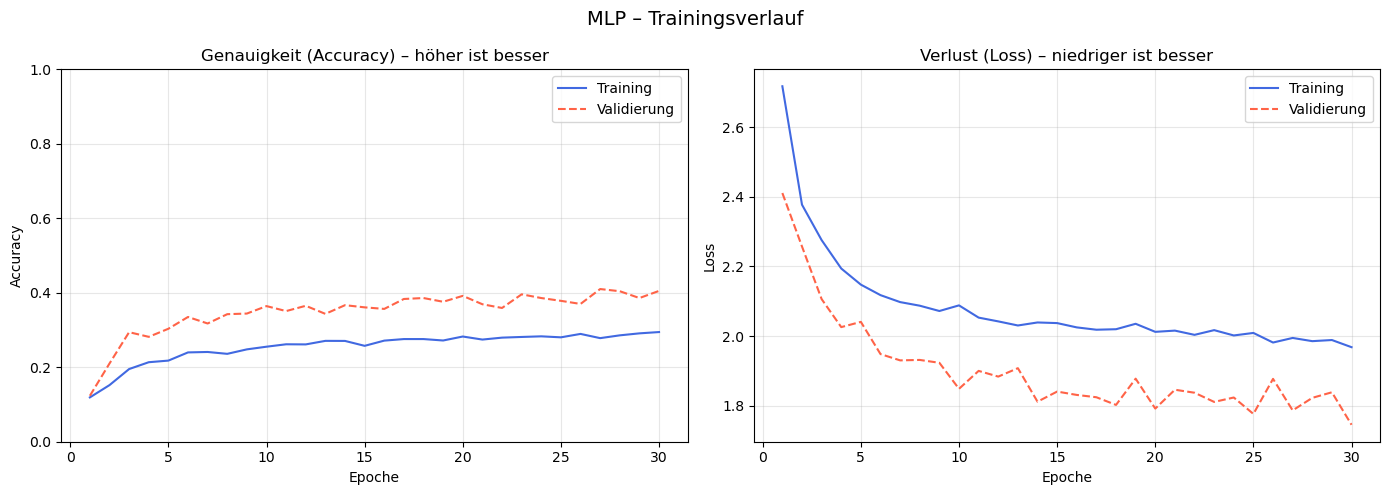

MLP – Endergebnis auf den Testdaten:
  Accuracy : 40.50 %
  Loss     : 1.7452


In [12]:
plot_history(history_mlp, title="MLP – Trainingsverlauf")

mlp_loss, mlp_acc = mlp_model.evaluate(val_ds, verbose=0)
print(f"MLP – Endergebnis auf den Testdaten:")
print(f"  Accuracy : {mlp_acc*100:.2f} %")
print(f"  Loss     : {mlp_loss:.4f}")

---

# Teil 2: Eigenes CNN

CNNs wurden speziell für Bilder entwickelt.
Sie erhalten die räumliche Struktur des Bildes.

Filter gleiten über das Bild und erkennen Muster wie:
- Kanten
- Ecken
- Strukturen
- Texturen

Je tiefer das Netz wird, desto komplexere Merkmale lernt es.

### Die wichtigsten Schichten

| Schicht | Was sie tut |
|---|---|
| `Conv2D` | Gleitet mit einem Filter über das Bild und sucht Muster |
| `BatchNormalization` | Stabilisiert das Training |
| `MaxPooling2D` | Halbiert die Bildgröße – reduziert Rechenaufwand |
| `GlobalAveragePooling2D` | Fasst alle Merkmale kompakt zusammen |

In [13]:
cnn_model = build_cnn(num_classes, IMG_SIZE_SMALL)
cnn_model.summary()

Model: "cnn_from_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ augmentation_small (Sequential)      │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_1 (Rescaling)              │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 12)                  │           1,548 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 424,780 (1.62 MB)

 Trainable params: 423,820 (1.62 MB)

 Non-trainable params: 960 (3.75 KB)

In [14]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"Starte CNN-Training ({CNN_EPOCHS} Epochen) ...")
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CNN_EPOCHS
)

Starte CNN-Training (30 Epochen) ...
Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 93s 453ms/step - accuracy: 0.3870 - loss: 1.8670 - val_accuracy: 0.0808 - val_loss: 2.6580
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 85s 450ms/step - accuracy: 0.4872 - loss: 1.5542 - val_accuracy: 0.2975 - val_loss: 2.0548
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 85s 454ms/step - accuracy: 0.5290 - loss: 1.4264 - val_accuracy: 0.5283 - val_loss: 1.3926
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 85s 451ms/step - accuracy: 0.5447 - loss: 1.3651 - val_accuracy: 0.5667 - val_loss: 1.2891
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 85s 450ms/step - accuracy: 0.5590 - loss: 1.3072 - val_accuracy: 0.5683 - val_loss: 1.3218
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 85s 453ms/step - accuracy: 0.5660 - loss: 1.2904 - val_accuracy: 0.5683 - val_loss: 1.2964
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 85s 450ms/step - accuracy: 0.5853 - loss: 1.2423 - val_accuracy: 0.5783 - val_loss: 1.2844
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 85s 45

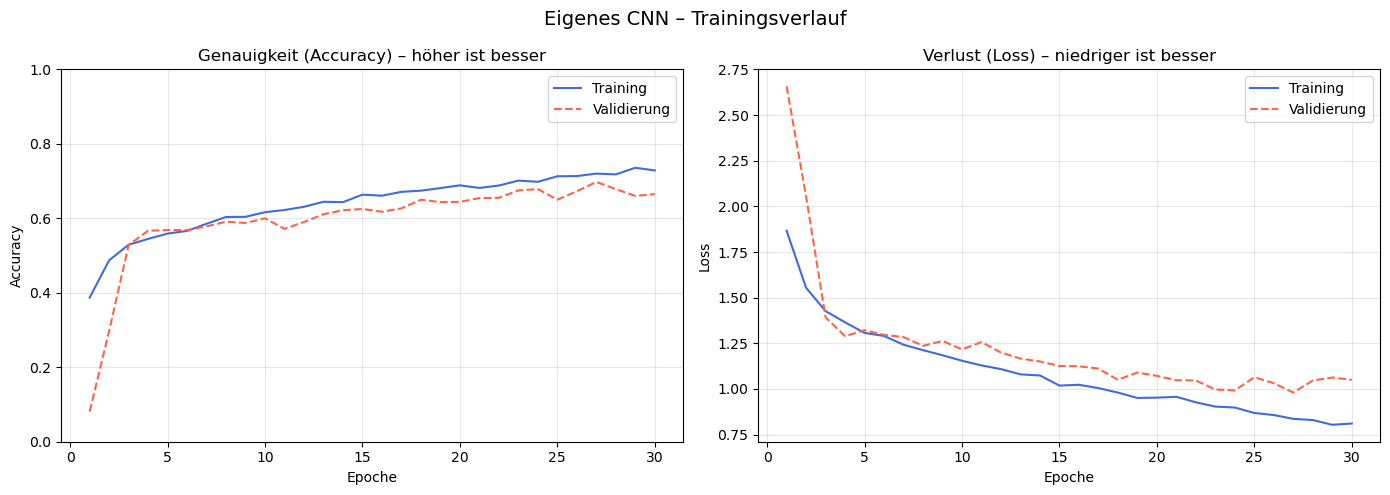

Eigenes CNN – Endergebnis auf den Testdaten:
  Accuracy : 66.50 %
  Loss     : 1.0500


In [15]:
plot_history(history_cnn, title="Eigenes CNN – Trainingsverlauf")

cnn_loss, cnn_acc = cnn_model.evaluate(val_ds, verbose=0)
print(f"Eigenes CNN – Endergebnis auf den Testdaten:")
print(f"  Accuracy : {cnn_acc*100:.2f} %")
print(f"  Loss     : {cnn_loss:.4f}")

---

# Teil 3: Transfer Learning mit EfficientNetB0

## Was ist Transfer Learning?

Beim **Transfer Learning** starten wir nicht bei Null,
sondern mit einem Modell, das bereits auf sehr vielen Bildern trainiert wurde.

Das Modell bringt also Vorwissen mit:
- Kanten
- Farben
- Texturen
- allgemeine Formen

Wir fügen dann nur einen neuen **Klassifikationskopf** hinzu,
der auf unsere spezifischen Müll-Klassen trainiert wird.

## Warum EfficientNetB0?

EfficientNetB0 ist ein modernes, kompaktes Modell,
das trotz seiner geringen Größe sehr gute Ergebnisse liefert.
Es wurde auf **ImageNet** vortrainiert – einem Datensatz
mit 1,4 Millionen Bildern und 1000 verschiedenen Klassen.

Die Standardbildgröße für EfficientNetB0 ist **224×224 Pixel**.
Wir verwenden genau diese Größe, damit das vortrainierte Wissen
optimal genutzt wird.

## Nur der Kopf wird trainiert

Das Basismodell bleibt vollständig eingefroren.
Wir trainieren **nur den neuen Klassifikationskopf**.

Das ist der Kern von Transfer Learning:
mit wenig eigenem Training sehr gute Ergebnisse erzielen.

## Vorverarbeitung bei EfficientNet

EfficientNet hat die Bildvorverarbeitung **bereits eingebaut**.
Es erwartet Pixelwerte von 0 bis 255 und normalisiert intern.
Darum brauchen wir hier **kein** `Rescaling`.

In [16]:
efficientnet_b0_model = build_efficientnet_b0(
    num_classes=num_classes,
    img_size=IMG_SIZE_TRANSFER,
    augmentation=data_augmentation_transfer,
    weights="imagenet"
)

# Basismodell anhand des Typs suchen – robust gegenüber Keras-Versionen
efficientnet_b0_base = next(
    l for l in efficientnet_b0_model.layers
    if isinstance(l, tf.keras.Model)
)

print(f"EfficientNetB0 geladen: {len(efficientnet_b0_base.layers)} Schichten")
print("Basismodell eingefroren: Nur der neue Kopf wird trainiert.")
efficientnet_b0_model.summary()

EfficientNetB0 geladen: 4 Schichten
Basismodell eingefroren: Nur der neue Kopf wird trainiert.


Model: "efficientnetb0_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ augmentation_transfer (Sequential)   │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 12)                  │          15,372 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,064,943 (15.51 MB)

 Trainable params: 15,372 (60.05 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [17]:
efficientnet_b0_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"Starte Transfer-Learning-Training ({TL_EPOCHS} Epochen) ...")
print("Das Basismodell ist eingefroren – nur der neue Klassifikationskopf lernt.")

history_tl = efficientnet_b0_model.fit(
    train_ds_transfer,
    validation_data=val_ds_transfer,
    epochs=TL_EPOCHS
)

Starte Transfer-Learning-Training (20 Epochen) ...
Das Basismodell ist eingefroren – nur der neue Klassifikationskopf lernt.
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 154s 695ms/step - accuracy: 0.7775 - loss: 0.8634 - val_accuracy: 0.9083 - val_loss: 0.3572
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 123s 657ms/step - accuracy: 0.9040 - loss: 0.3532 - val_accuracy: 0.9283 - val_loss: 0.2573
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 123s 656ms/step - accuracy: 0.9208 - loss: 0.2726 - val_accuracy: 0.9392 - val_loss: 0.2151
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 123s 657ms/step - accuracy: 0.9352 - loss: 0.2300 - val_accuracy: 0.9400 - val_loss: 0.2020
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 123s 655ms/step - accuracy: 0.9423 - loss: 0.2031 - val_accuracy: 0.9417 - val_loss: 0.1871
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 124s 660ms/step - accuracy: 0.9463 - loss: 0.1819 - val_accuracy: 0.9417 - val_loss: 0.1785
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 123s 657ms/step - accuracy: 0.9488 - loss: 

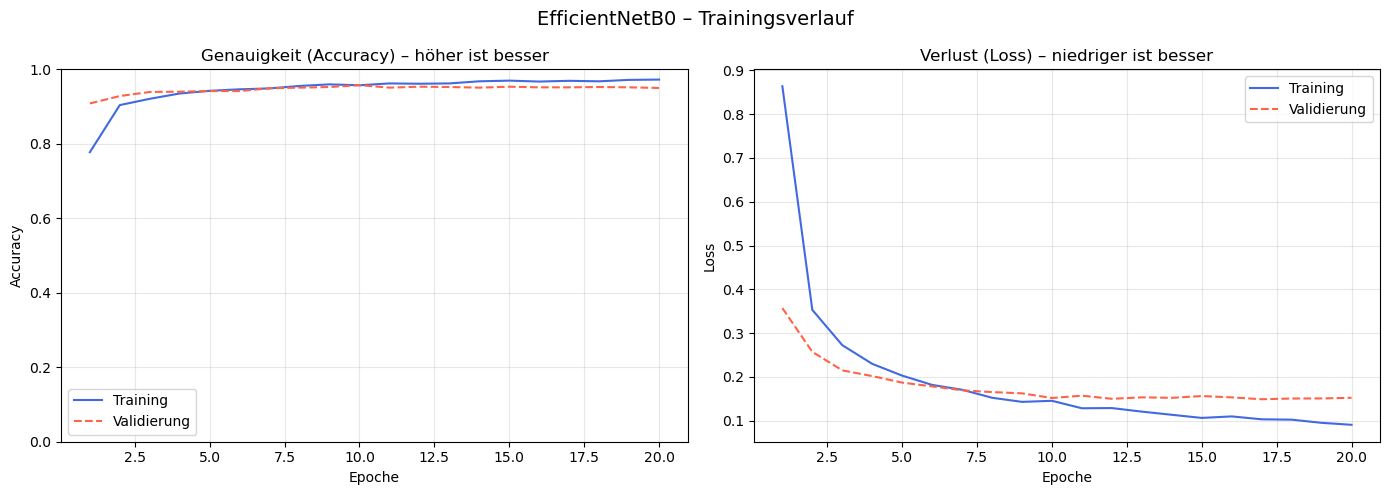

EfficientNetB0 – Endergebnis auf den Testdaten:
  Accuracy : 95.00 %
  Loss     : 0.1526


In [18]:
plot_history(history_tl, title="EfficientNetB0 – Trainingsverlauf")

tl_loss, tl_acc = efficientnet_b0_model.evaluate(val_ds_transfer, verbose=0)
print(f"EfficientNetB0 – Endergebnis auf den Testdaten:")
print(f"  Accuracy : {tl_acc*100:.2f} %")
print(f"  Loss     : {tl_loss:.4f}")

---

# Vergleich aller drei Modelle

Jetzt vergleichen wir alle Modelle direkt.

Typischerweise erwarten wir:

```text
MLP  <  Eigenes CNN  <  EfficientNetB0
```

Je mehr Bildverständnis und Vorwissen ein Modell mitbringt,
desto besser schneidet es meist ab.

  Modell                   Accuracy
  1. MLP                     40.50 %
  2. Eigenes CNN             66.50 %
  3. EfficientNetB0          95.00 %

  Bestes Modell: 3. EfficientNetB0


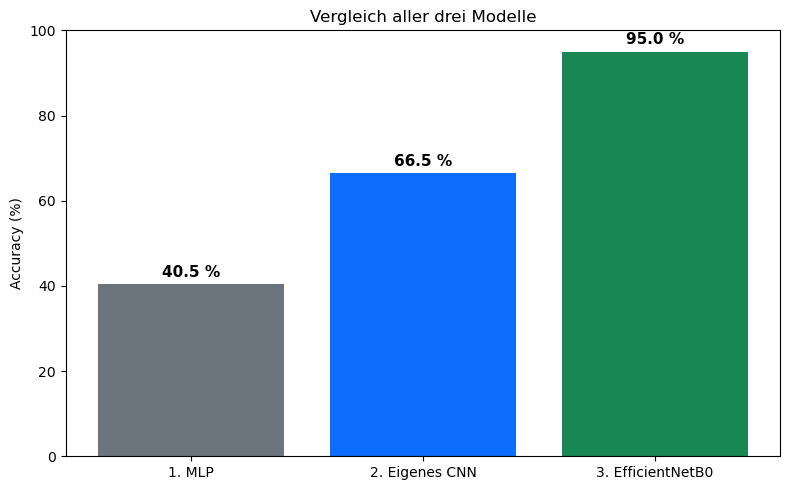

In [19]:
results = {
    "1. MLP":            mlp_acc,
    "2. Eigenes CNN":    cnn_acc,
    "3. EfficientNetB0": tl_acc,
}

farben = ["#6c757d", "#0d6efd", "#198754"]

print("=" * 45)
print(f"  {'Modell':<22} {'Accuracy':>10}")
print("=" * 45)
for name, acc in results.items():
    print(f"  {name:<22} {acc*100:>9.2f} %")
print("=" * 45)
print(f"\n  Bestes Modell: {max(results, key=results.get)}")

plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(), [v * 100 for v in results.values()], color=farben)
plt.ylabel("Accuracy (%)")
plt.title("Vergleich aller drei Modelle")
plt.ylim(0, 100)
for bar, val in zip(bars, results.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val*100:.1f} %",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )
plt.tight_layout()
plt.show()

---

# Detaillierte Auswertung: Confusion Matrix

Die Accuracy allein sagt nur, **wie viele** Bilder insgesamt richtig erkannt wurden.
Aber sie sagt nicht, **welche Klassen** häufig verwechselt werden.

Dafür nutzen wir die **Confusion Matrix**.

- Diagonale = richtige Vorhersagen
- Werte außerhalb der Diagonalen = Verwechslungen

Zusätzlich betrachten wir den **Classification Report** mit:
- **Precision** – wie zuverlässig sind die Vorhersagen einer Klasse?
- **Recall** – wie vollständig werden Bilder einer Klasse gefunden?
- **F1-Score** – Gesamtnote aus Precision und Recall

Wir machen diese Analyse für das **beste Modell**.

Auswertung für: 3. EfficientNetB0
Berechne Vorhersagen ...
38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 627ms/step


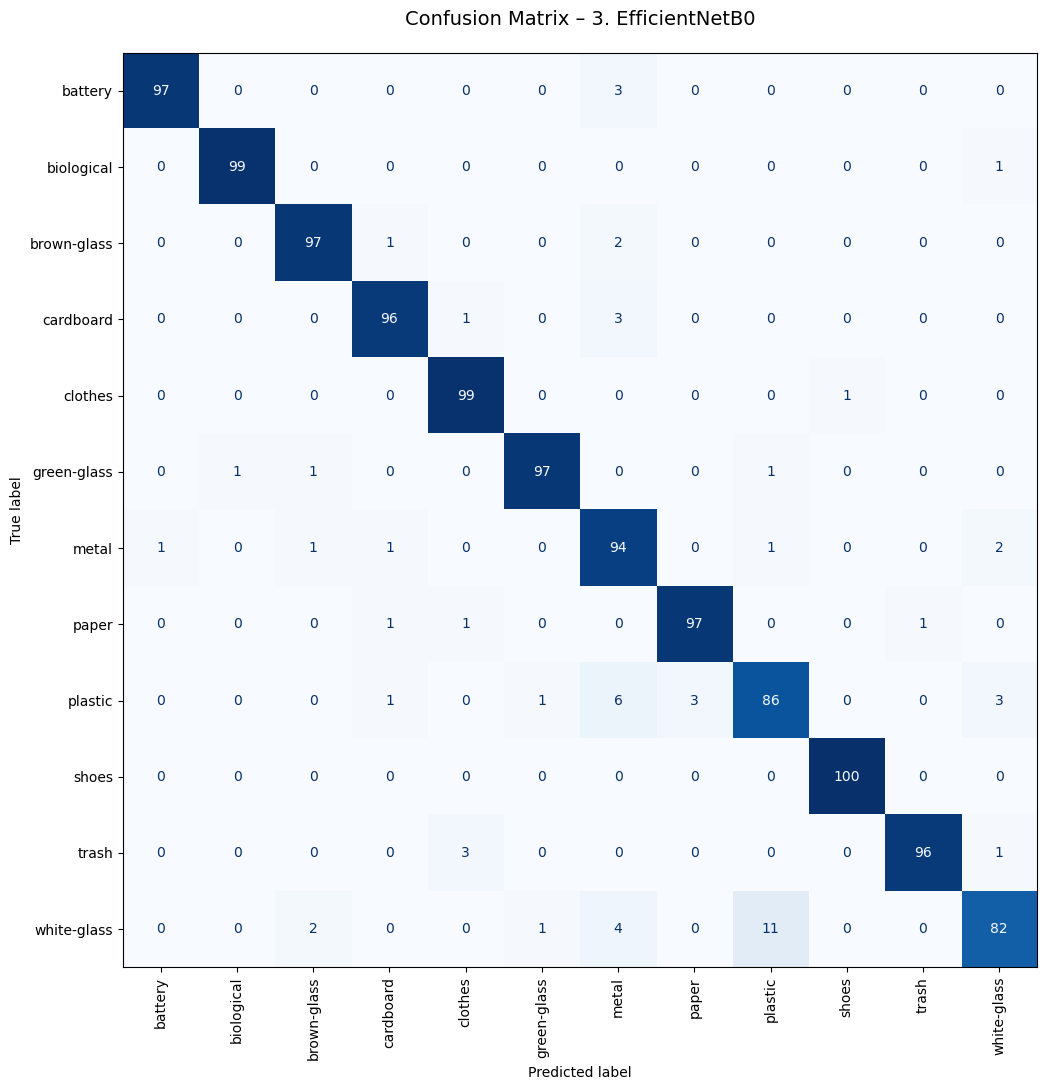


Classification Report:
              precision    recall  f1-score   support

     battery       0.99      0.97      0.98       100
  biological       0.99      0.99      0.99       100
 brown-glass       0.96      0.97      0.97       100
   cardboard       0.96      0.96      0.96       100
     clothes       0.95      0.99      0.97       100
 green-glass       0.98      0.97      0.97       100
       metal       0.84      0.94      0.89       100
       paper       0.97      0.97      0.97       100
     plastic       0.87      0.86      0.86       100
       shoes       0.99      1.00      1.00       100
       trash       0.99      0.96      0.97       100
 white-glass       0.92      0.82      0.87       100

    accuracy                           0.95      1200
   macro avg       0.95      0.95      0.95      1200
weighted avg       0.95      0.95      0.95      1200



In [20]:
modelle = {
    "1. MLP":            (mlp_model,             val_ds),
    "2. Eigenes CNN":    (cnn_model,             val_ds),
    "3. EfficientNetB0": (efficientnet_b0_model, val_ds_transfer),
}

bestes_name               = max(results, key=results.get)
bestes_modell, bestes_val = modelle[bestes_name]
print(f"Auswertung für: {bestes_name}")

print("Berechne Vorhersagen ...")
y_pred_probs = bestes_modell.predict(bestes_val, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y.numpy() for _, y in bestes_val], axis=0)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(13, 11))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation="vertical", ax=plt.gca(), colorbar=False)
plt.title(f"Confusion Matrix – {bestes_name}", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

---

# Vorhersagen visualisieren

Zahlen und Diagramme sind wichtig –
aber am eindrucksvollsten ist es, die tatsächlichen Bilder
neben der Modellentscheidung zu sehen.

**Grün** = richtig klassifiziert
**Rot** = falsch klassifiziert

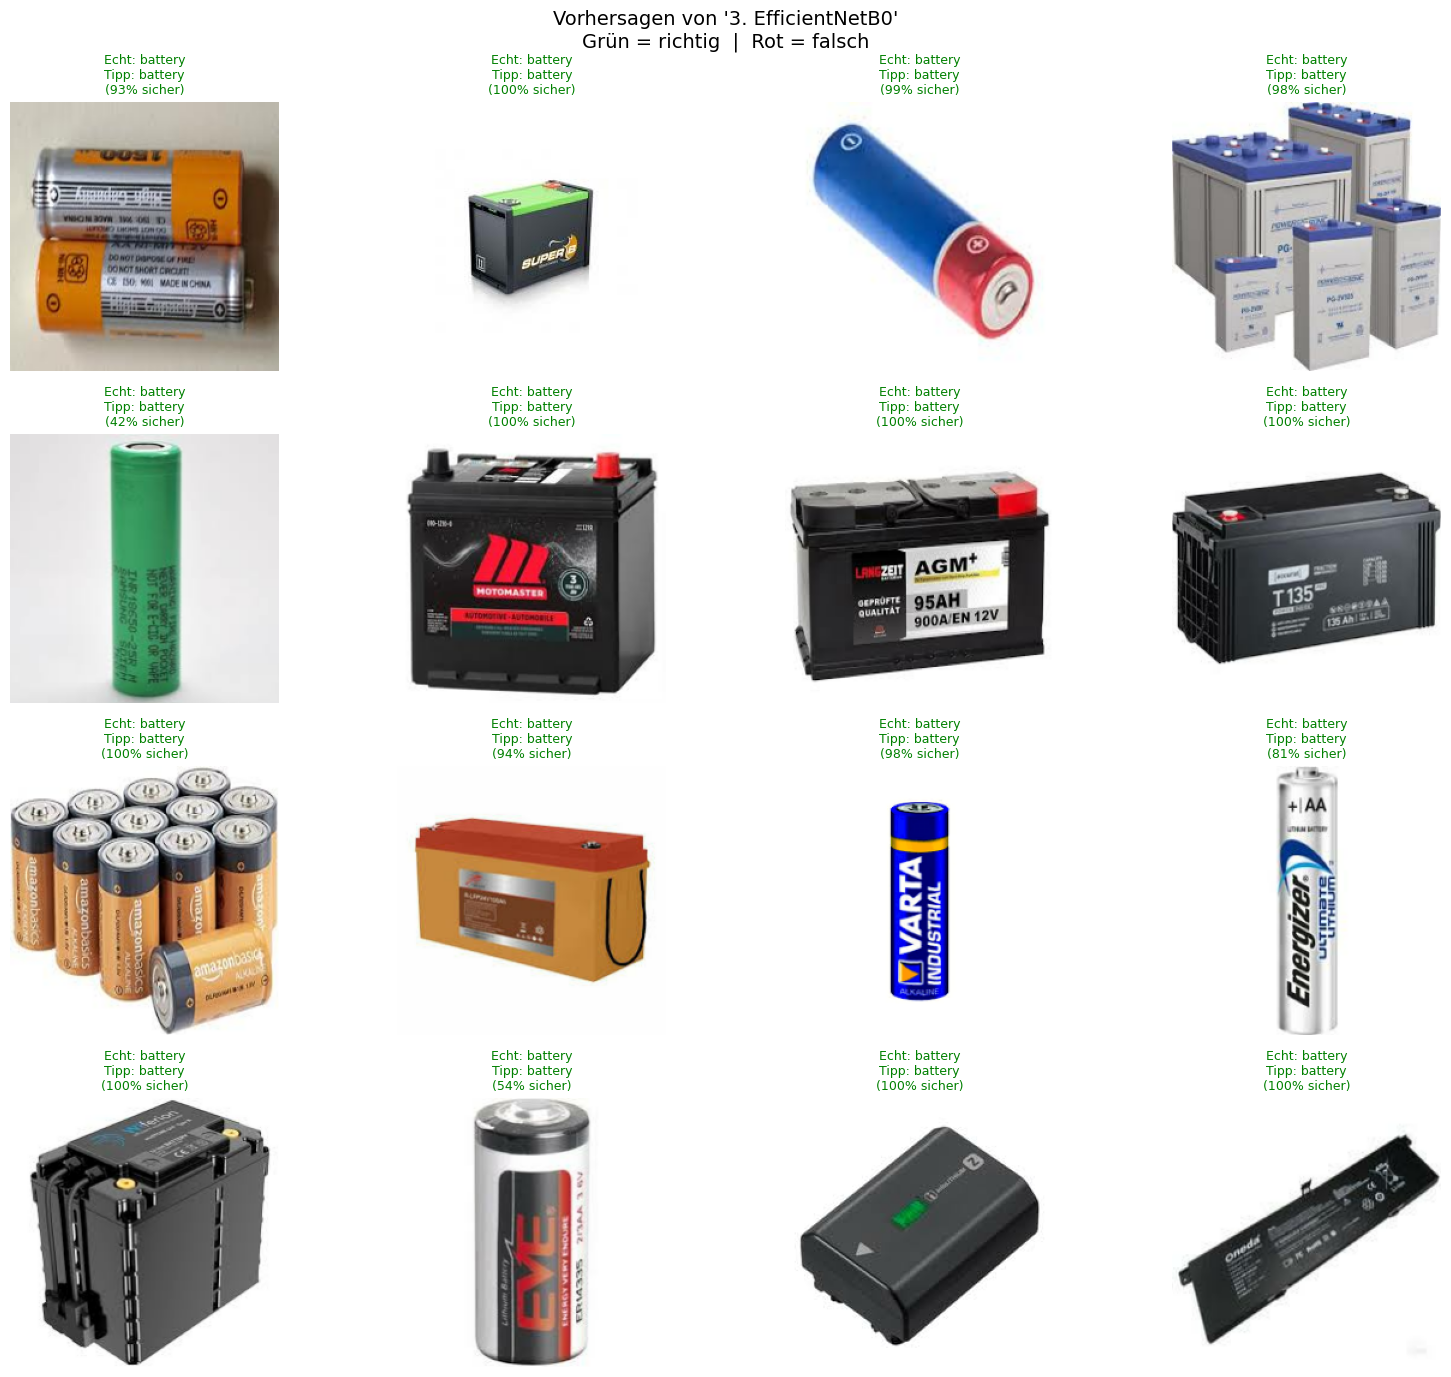

In [21]:
for bilder, labels in bestes_val.take(1):
    batch_bilder = bilder.numpy()
    batch_labels = labels.numpy()

preds    = bestes_modell.predict(batch_bilder, verbose=0)
n_zeigen = min(16, len(batch_bilder))

plt.figure(figsize=(16, 14))
plt.suptitle(
    f"Vorhersagen von '{bestes_name}'\n"
    "Grün = richtig  |  Rot = falsch",
    fontsize=14
)

for i in range(n_zeigen):
    plt.subplot(4, 4, i + 1)
    plt.imshow(batch_bilder[i].astype("uint8"))
    plt.axis("off")
    echte_klasse = class_names[batch_labels[i]]
    pred_klasse  = class_names[np.argmax(preds[i])]
    konfidenz    = np.max(preds[i]) * 100
    farbe        = "green" if echte_klasse == pred_klasse else "red"
    plt.title(
        f"Echt: {echte_klasse}\nTipp: {pred_klasse}\n({konfidenz:.0f}% sicher)",
        color=farbe, fontsize=9
    )

plt.tight_layout()
plt.show()

---

# Fehleranalyse: falsch klassifizierte Bilder pro Klasse

Hier schauen wir uns systematisch die Fehler des besten Modells an.
Das hilft uns zu verstehen, **wo** das Modell unsicher oder systematisch falsch liegt.

Bestes Modell : 3. EfficientNetB0
Fehler gesamt : 60 von 1200 (5.0 %)


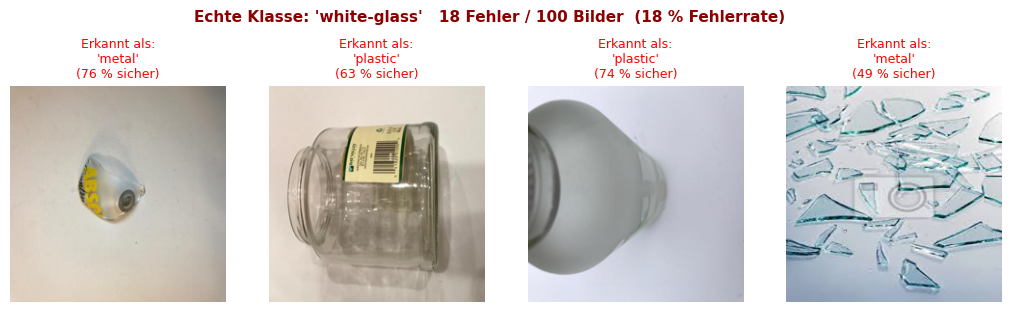

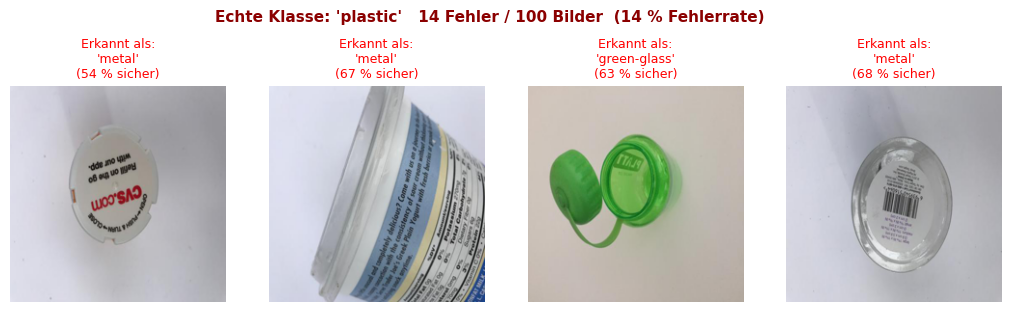

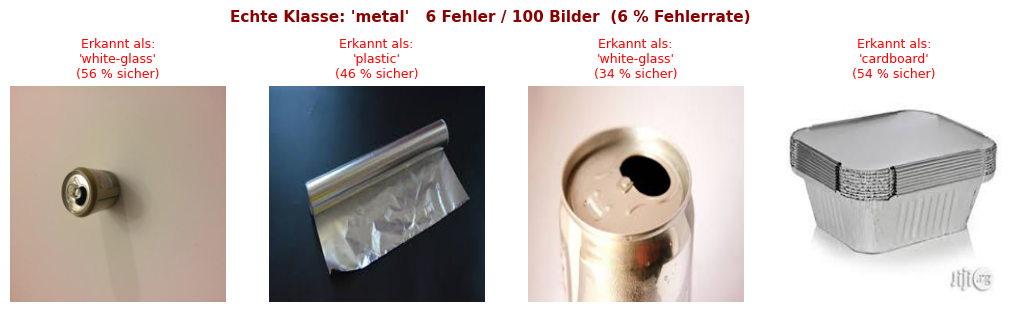

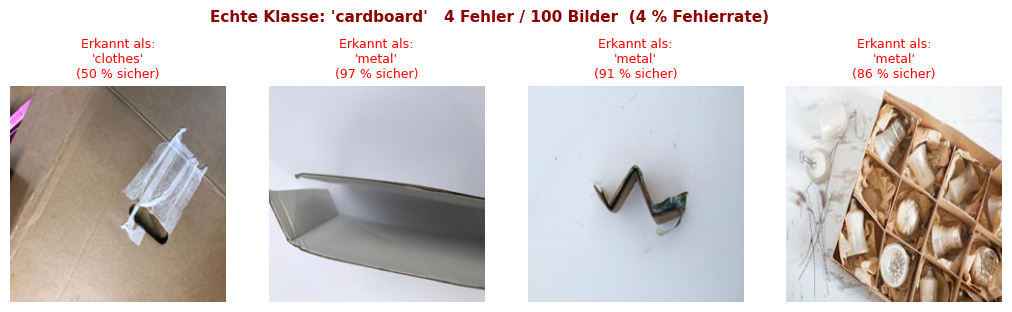

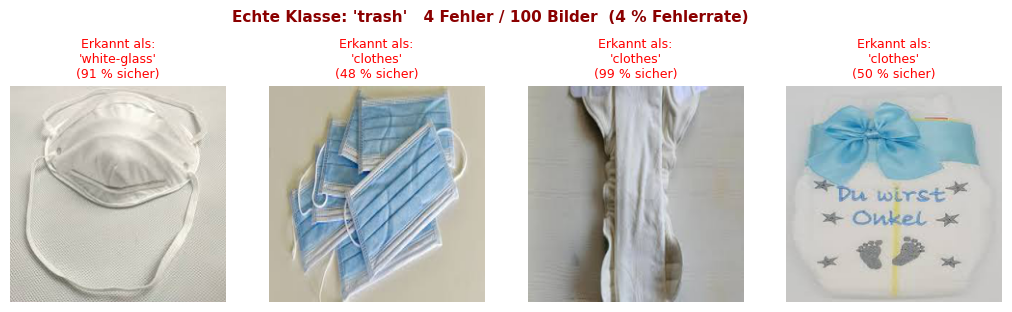

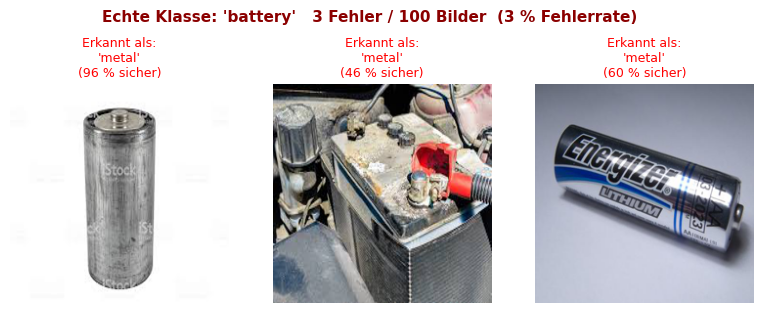

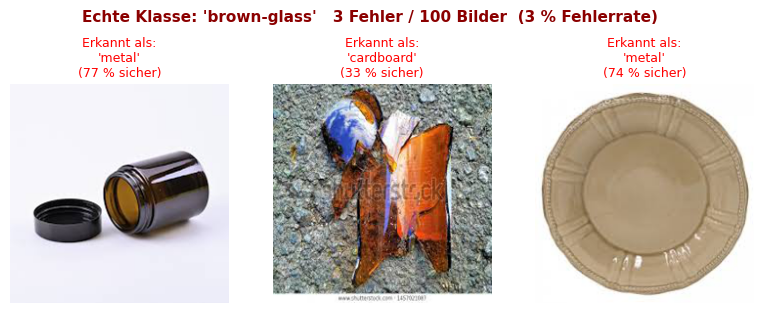

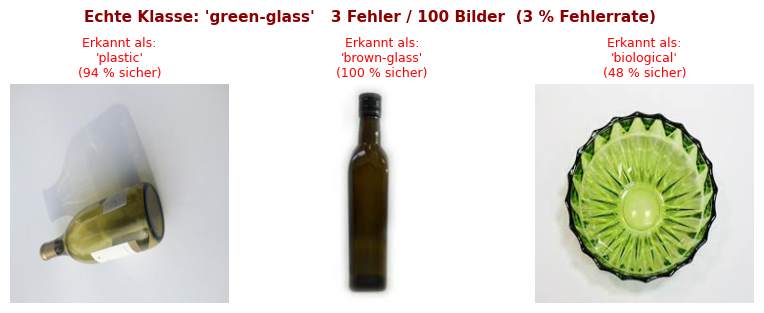

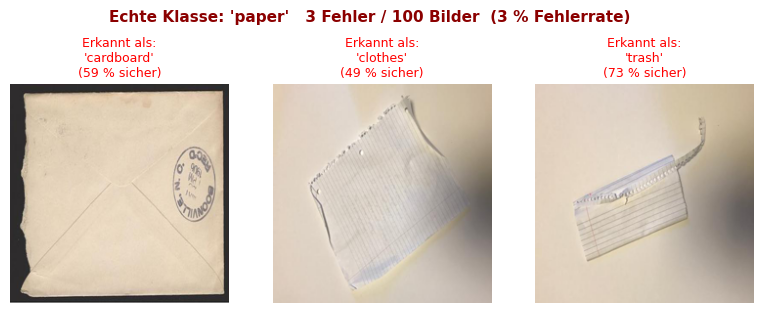

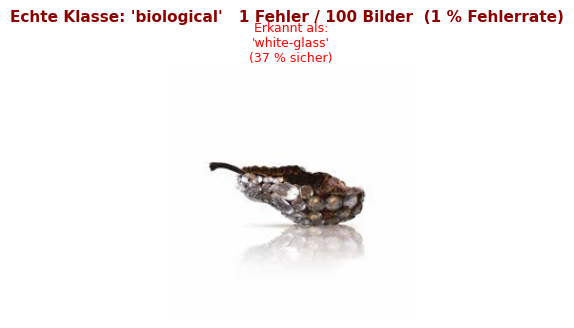

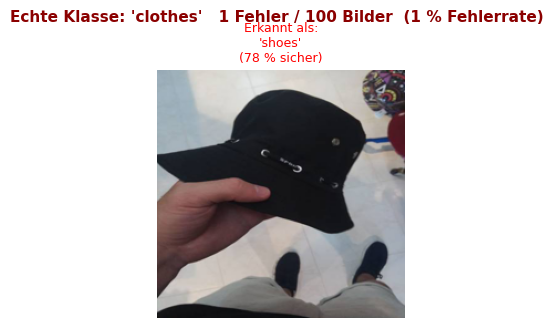

In [22]:
from PIL import Image

MAX_PRO_KLASSE = 4

alle_bild_pfade = []
for klassen_idx, klassen_name in enumerate(class_names):
    for pfad in sorted((TEST_DIR / klassen_name).glob("*.*")):
        alle_bild_pfade.append((pfad, klassen_idx))

fehler_pro_klasse = {name: [] for name in class_names}

for idx, (pfad, echter_label) in enumerate(alle_bild_pfade):
    if echter_label != y_pred[idx]:
        bild = np.array(Image.open(pfad).convert("RGB").resize((224, 224)))
        fehler_pro_klasse[class_names[echter_label]].append(
            (bild, class_names[y_pred[idx]], float(np.max(y_pred_probs[idx])) * 100)
        )

klassen_mit_fehlern = sorted(
    [(n, f) for n, f in fehler_pro_klasse.items() if f],
    key=lambda x: len(x[1]), reverse=True
)

gesamt_fehler = sum(len(f) for _, f in klassen_mit_fehlern)
print(f"Bestes Modell : {bestes_name}")
print(f"Fehler gesamt : {gesamt_fehler} von {len(alle_bild_pfade)} "
      f"({gesamt_fehler / len(alle_bild_pfade) * 100:.1f} %)")

for klasse, fehler in klassen_mit_fehlern:
    n_zeigen      = min(MAX_PRO_KLASSE, len(fehler))
    klasse_idx    = class_names.index(klasse)
    bilder_gesamt = label_counts[klasse_idx]
    fehlerrate    = len(fehler) / bilder_gesamt * 100

    fig, axes = plt.subplots(1, n_zeigen, figsize=(n_zeigen * 3.2, 3.8), squeeze=False)
    fig.suptitle(
        f"Echte Klasse: '{klasse}'   "
        f"{len(fehler)} Fehler / {bilder_gesamt} Bilder  ({fehlerrate:.0f} % Fehlerrate)",
        fontsize=11, fontweight="bold", color="darkred"
    )
    for ax, (bild_array, pred_klasse, konfidenz) in zip(axes[0], fehler[:n_zeigen]):
        ax.imshow(bild_array)
        ax.axis("off")
        ax.set_title(
            f"Erkannt als:\n'{pred_klasse}'\n({konfidenz:.0f} % sicher)",
            fontsize=9, color="red"
        )
    plt.show()

---

# Modelle speichern – modern und zukunftsfähig

Wir speichern jedes Modell in **zwei Formaten**:

| Format | Inhalt | Verwendung |
|---|---|---|
| `.keras` | Architektur + Gewichte | Modernes Keras-3-Standardformat |
| `.weights.h5` | Nur Gewichte | Demo-Notebook, immer kompatibel |

Zusätzlich speichern wir `model_config.json` mit:
- Anzahl Klassen
- Bildgrößen
- Klassennamen

Damit ist das Demo-Notebook unabhängig von hart kodierten Werten.
Je nach Version von Tensorflow kann es vorkommen, dass sonst die Modelle nicht richtig geladen werden können.

In [23]:
print("Speichere alle Modelle im modernen Doppel-Format ...")

# --- 1) Modernes Keras-Standardformat (.keras) ---
mlp_model.save("modell_01_mlp.keras")
cnn_model.save("modell_02_cnn.keras")
efficientnet_b0_model.save("modell_03_efficientnetb0.keras")

# --- 2) Robustes Gewichtsformat (.weights.h5) ---
mlp_model.save_weights("modell_01_mlp.weights.h5")
cnn_model.save_weights("modell_02_cnn.weights.h5")
efficientnet_b0_model.save_weights("modell_03_efficientnetb0.weights.h5")

# --- Konfiguration für das Demo-Notebook ---
model_config = {
    "num_classes": num_classes,
    "img_size_small": list(IMG_SIZE_SMALL),
    "img_size_transfer": list(IMG_SIZE_TRANSFER),
    "class_names": class_names
}
with open("model_config.json", "w", encoding="utf-8") as f:
    json.dump(model_config, f, ensure_ascii=False, indent=2)

print("Fertig! Gespeicherte Dateien:")
print("  modell_01_mlp.keras")
print("  modell_02_cnn.keras")
print("  modell_03_efficientnetb0.keras")
print("  modell_01_mlp.weights.h5")
print("  modell_02_cnn.weights.h5")
print("  modell_03_efficientnetb0.weights.h5")
print("  model_config.json")
print()
print("Das Demo-Notebook lädt die .weights.h5-Dateien.")
print("Die .keras-Dateien sind das moderne Standardformat als Voll-Backup.")

Speichere alle Modelle im modernen Doppel-Format ...
Fertig! Gespeicherte Dateien:
  modell_01_mlp.keras
  modell_02_cnn.keras
  modell_03_efficientnetb0.keras
  modell_01_mlp.weights.h5
  modell_02_cnn.weights.h5
  modell_03_efficientnetb0.weights.h5
  model_config.json

Das Demo-Notebook lädt die .weights.h5-Dateien.
Die .keras-Dateien sind das moderne Standardformat als Voll-Backup.


---

# Fazit

## Die drei Modelle im Überblick

### 1. MLP
Einfach, aber für Bilder nicht optimal, weil räumliche Struktur verloren geht.

### 2. Eigenes CNN
Speziell für Bilddaten gebaut und deshalb deutlich besser geeignet.

### 3. EfficientNetB0
Bringt Vorwissen mit und erreicht mit wenig Training starke Ergebnisse.
Verwendet die Standardbildgröße 224×224 Pixel.

---

## Nächste Schritte

- Mehr Daten sammeln – besonders für Klassen mit schwachem F1-Score
- Das beste Modell live mit OpenCV testen
- Eigene Bilder aufnehmen, um damit ein Modell für eine andere Aufgabe zu trainieren.